****Part 1: PROJECT INTRODUCTION AND SETUP****

In [1]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1" 
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, classification_report

import os
import shutil
from tqdm import tqdm

from lime import lime_image
from skimage.segmentation import mark_boundaries
import tensorflow_hub as hub

print("Imports loaded successfully!")

2025-11-24 13:30:15.850677: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763991016.029933      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763991016.083296      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Imports loaded successfully!


****PART 2: DATA PREPARATION AND LOADING****

In [2]:
# Configuration Parameters
DATA_DIR = "/kaggle/input/cactus-final/Cactus_final"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 75
CHANNELS = 3
CLASS_NAMES = ['Affected', 'Healthy', 'No cactus']
K_FOLDS = 5

# Loading Data for K-Fold Cross-Validation
images = []
labels = []
class_to_label = {name: i for i, name in enumerate(CLASS_NAMES)}

for class_name, label_index in class_to_label.items():
    class_path = os.path.join(DATA_DIR, class_name)  # Replace temp_data_dir with DATA_DIR here
    for img_file in tqdm(os.listdir(class_path), desc=f"Loading {class_name} images"):
        img_path = os.path.join(class_path, img_file)
        img = image.load_img(img_path, target_size=IMAGE_SIZE)
        img_array = image.img_to_array(img) / 255.0
        images.append(img_array)
        labels.append(label_index)

X = np.array(images)
y = np.array(labels)
print(f"Dataset loaded: {X.shape[0]} images found.")

Loading No cactus images: 100%|██████████| 587/587 [00:05<00:00, 115.48it/s]


Dataset loaded: 3587 images found.


****PART 3: MODEL DEFINITION & SETUP (EfficientNet-Lite1)****

In [3]:
# EfficientNet-Lite1 URL from TensorFlow Hub
EFFNET_LITE1_URL = "https://tfhub.dev/tensorflow/efficientnet/lite1/feature-vector/2"

# Defining checkpoint path
checkpoint_path = "best_cactus_effnet_lite1.keras"

# Callbacks (Same as before for fair comparison)
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True),
    ModelCheckpoint(
        checkpoint_path,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
]

def create_model():
    """
    Creating an EfficientNet-Lite1 model for Transfer Learning.
    The backbone is frozen (trainable=False) to act as a feature extractor.
    """
    model = models.Sequential([
        # Explicit Input Layer
        layers.InputLayer(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)),
        
        # 1. The Pre-trained EfficientNet-Lite1 Backbone
        hub.KerasLayer(EFFNET_LITE1_URL, trainable=False),
        
        # 2. Classification Head (Customized for your Cactus Dataset)
        layers.Dropout(0.2), # Dropout is crucial for EfficientNet to prevent overfitting
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.4),
        layers.Dense(len(CLASS_NAMES), activation='softmax')
    ])
    
    # Compile with the same settings as your Vanilla CNN for fair benchmarking
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Initialize K-Fold and variables (Same as before)
kfold = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
fold_accuracies = []
fold_histories = []
best_model = None
best_accuracy = 0.0
best_fold_history = None
fold = 1

print("EfficientNet-Lite1 Model setup complete. Ready for training...")

EfficientNet-Lite1 Model setup complete. Ready for training...


**Data Augumentation Techniques!**

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)
print("The sufficient paper.")

The sufficient paper.


**PART 4: TRAINING LOOP (CROSS-VALIDATION)**

In [5]:
initial_epoch = 0

for train_index, val_index in kfold.split(X, y):
    print(f"\n--- Training Fold {fold}/{K_FOLDS} ---")
    
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]
    
    # Creating fresh model for each fold
    model = create_model()
    
    # Augmentation generator
    train_generator = datagen.flow(X_train, y_train, batch_size=BATCH_SIZE)
    
    history = model.fit(
        train_generator,
        epochs=EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=callbacks,
        verbose=1
    )

    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    print(f"Fold {fold} - Validation Accuracy: {accuracy:.4f}")
    
    fold_accuracies.append(accuracy)
    fold_histories.append(history)

    # Save best model globally
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = model
        model.save('best_cactus_effnet_final.keras')
        print(">> New Global Best Model Saved!")
        
    fold += 1

print(f"\n--- Cross-Validation Complete ---")
print(f"Average Accuracy: {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")


--- Training Fold 1/5 ---


I0000 00:00:1763991073.726909      48 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Epoch 1/75


I0000 00:00:1763991079.764788     106 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1763991081.979045     108 service.cc:148] XLA service 0x7927bc4d8b40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763991081.979569     108 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1763991082.150358     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


90/90 [==============================] - ETA: 0s - loss: 1.0507 - accuracy: 0.6208
Epoch 1: val_accuracy improved from -inf to 0.75627, saving model to best_cactus_effnet_lite1.keras
90/90 [==============================] - 34s 322ms/step - loss: 1.0507 - accuracy: 0.6208 - val_loss: 0.7855 - val_accuracy: 0.7563
Epoch 2/75
90/90 [==============================] - ETA: 0s - loss: 0.7206 - accuracy: 0.7999
Epoch 2: val_accuracy improved from 0.75627 to 0.80780, saving model to best_cactus_effnet_lite1.keras
90/90 [==============================] - 27s 304ms/step - loss: 0.7206 - accuracy: 0.7999 - val_loss: 0.6679 - val_accuracy: 0.8078
Epoch 3/75
90/90 [==============================] - ETA: 0s - loss: 0.6384 - accuracy: 0.8299
Epoch 3: val_accuracy improved from 0.80780 to 0.83705, saving model to best_cactus_effnet_lite1.keras
90/90 [==============================] - 27s 303ms/step - loss: 0.6384 - accuracy: 0.8299 - val_loss: 0.6133 - val_accuracy: 0.8370
Epoch 4/75
90/90 [=========

**PART 5: EVALUATION AND LIME EXPLAINABILITY**


--- Final Evaluation on Test Set (Last Fold) ---
23/23 [==============================] - 1s 27ms/step


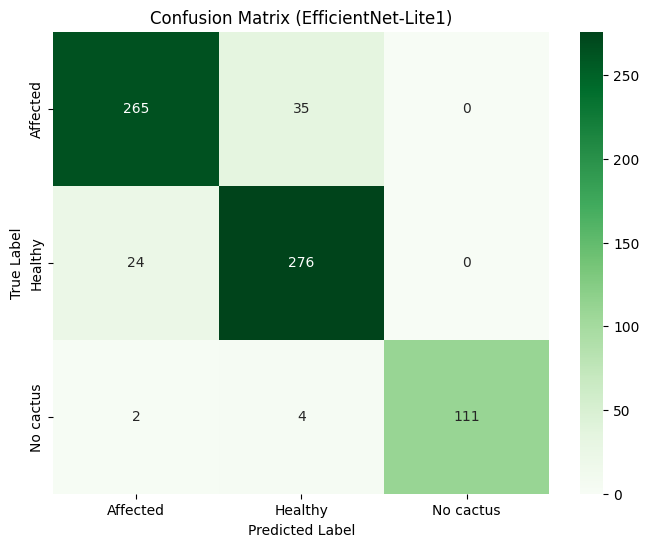


Classification Report:

              precision    recall  f1-score   support

    Affected       0.91      0.88      0.90       300
     Healthy       0.88      0.92      0.90       300
   No cactus       1.00      0.95      0.97       117

    accuracy                           0.91       717
   macro avg       0.93      0.92      0.92       717
weighted avg       0.91      0.91      0.91       717


--- Generating LIME Explanations ---
Explaining Image Index 0 (True Class: Affected)


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 [==============================] - 0s 23ms/step


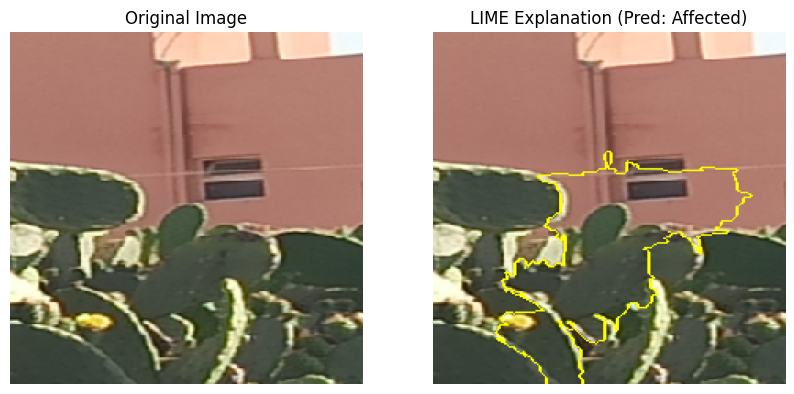

In [6]:
print("\n--- Final Evaluation on Test Set (Last Fold) ---")

# Load the best model
final_model = tf.keras.models.load_model(
    "best_cactus_effnet_final.keras",
    custom_objects={"KerasLayer": hub.KerasLayer},
    safe_mode=False,
    compile=False
)

# Use the validation set of the last fold as a proxy for test set visualization
X_test = X_val
y_test = y_val

# Predictions
y_pred_probs = final_model.predict(X_test)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix (EfficientNet-Lite1)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=CLASS_NAMES))

# LIME Setup
print("\n--- Generating LIME Explanations ---")

explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    return final_model.predict(images)

# Pick a sample index (e.g., first image in test set)
idx = 0 
print(f"Explaining Image Index {idx} (True Class: {CLASS_NAMES[y_test[idx]]})")

try:
    explanation = explainer.explain_instance(
        X_test[idx].astype('double'), 
        predict_fn, 
        top_labels=3, 
        hide_color=0, 
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0], 
        positive_only=True, 
        num_features=5, 
        hide_rest=False
    )

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(X_test[idx])
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(f'LIME Explanation (Pred: {CLASS_NAMES[y_pred_classes[idx]]})')
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"LIME Error: {e}")